                                                                                             Продукт  Норма_кг_год  Норма_г_день_окр
Хлебные продукты (хлеб и макаронные изделия в пересчете на муку, мука, крупы, бобовые), в том числе:          96.0               263
                                              мука для выпечки хлеба и кондитерских изделий из неё*:          64.0               175
                                                                                              ржаная          20.0                55
                                                                             пшеничная, в том числе:          44.0               120
                                                                   мука пшеничная витаминизированная          24.0                66
                                                   крупы, макаронные изделия и бобовые, в том числе:          32.0                88
                                                                     

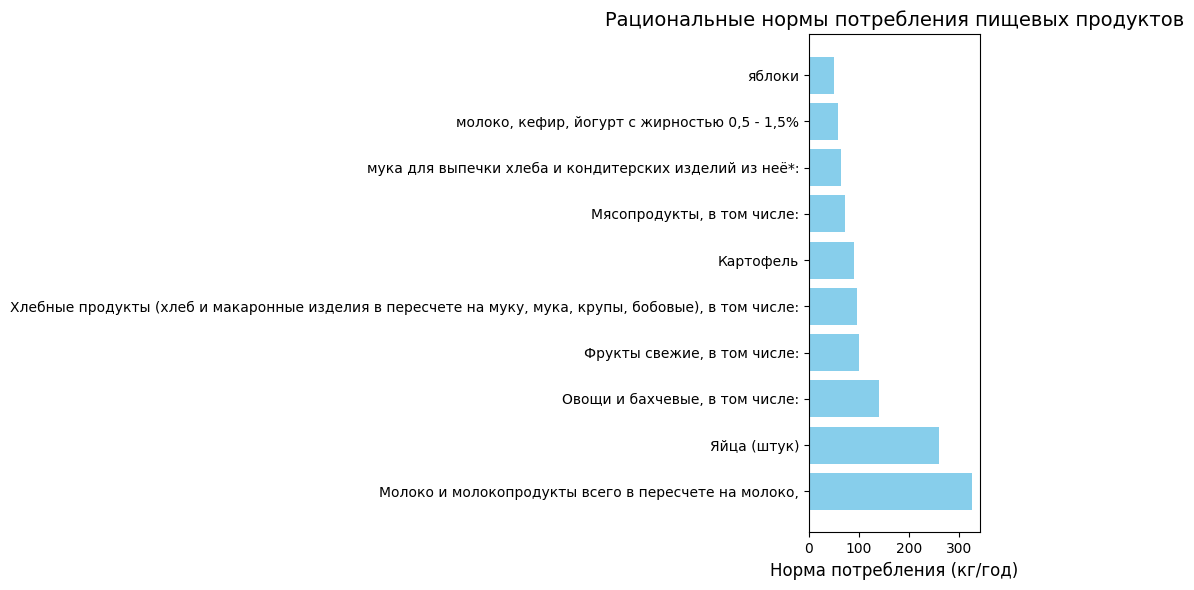

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import matplotlib.pyplot as plt

url = "https://www.37fbuz.ru/o-tsentre/rekomendatsii-grazhdanam/746-rekomenduemye-ratsionalnye-normy-potrebleniya-pishchevykh-produktov-otvechayushchikh-sovremennym-trebovaniyam-zdorovogo-pitaniya"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}


response = requests.get(url, headers=headers, timeout=15)
response.raise_for_status()
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.find_all('table')
target_table = None
for table in tables:
    if 'хлебные продукты' in table.get_text().lower():
        target_table = table
        break

if target_table is None and len(tables) > 0:
    target_table = tables[0]

if target_table is None:
    exit()

rows = target_table.find_all('tr')
data = []

for row in rows:
    cells = row.find_all('td')
    if len(cells) >= 3:
        product = cells[1].get_text(strip=True)
        norm_text = cells[2].get_text(strip=True)

        if not product or product == 'Наименование продуктов':
            continue

        numbers = re.findall(r'(\d+[\.,]?\d*)', norm_text)
        if numbers:
            norm_value = float(numbers[0].replace(',', '.'))
            product = re.sub(r'\s+', ' ', product).strip()
            data.append({
                'Продукт': product,
                'Норма_кг_год': norm_value,
                'Сырая_норма': norm_text
            })

df = pd.DataFrame(data)
if len(df) == 0:
    with open("table_debug.html", "w", encoding="utf-8") as f:
        f.write(str(target_table))
else:
    #Перевод из кг в год в граммы в день
    df['Норма_г_день'] = (df['Норма_кг_год'] * 1000 / 365).round(1)
    df['Норма_г_день_окр'] = df['Норма_г_день'].round(0).astype(int)
    print(df[['Продукт', 'Норма_кг_год', 'Норма_г_день_окр']].to_string(index=False)) #head(20).

    key_products = {
        'Хлебные продукты': 'хлебные',
        'Картофель': 'картофель',
        'Овощи и бахчевые': 'овощи',
        'Фрукты свежие': 'фрукты',
        'Сахар': 'сахар',
        'Мясопродукты': 'мясопродукты',
        'Рыбопродукты': 'рыбопродукты',
        'Молоко и молокопродукты': 'молоко',
        'Яйца': 'яйца',
        'Масло растительное': 'масло'
    }

    for display_name, search_term in key_products.items():
        rows = df[df['Продукт'].str.lower().str.contains(search_term, na=False)]
        if not rows.empty:
            row = rows.iloc[0]
            print(f"{display_name}: {row['Норма_кг_год']:.0f} кг/год = {row['Норма_г_день_окр']} г/день")
    df.to_csv('nutrition_standards.csv', index=False, encoding='utf-8-sig')

    if len(df) > 0:
        top_products = df.nlargest(10, 'Норма_кг_год')
        plt.figure(figsize=(10, 6))
        plt.barh(top_products['Продукт'], top_products['Норма_кг_год'], color='skyblue')
        plt.xlabel('Норма потребления (кг/год)', fontsize=12)
        plt.title('Рациональные нормы потребления пищевых продуктов', fontsize=14)
        plt.tight_layout()
        plt.savefig('nutrition_chart.png', dpi=100)
        plt.show()

В целом для рассчета издержек на пропитание и сотрудников и проживающих достаточно перемножить данные из рациона по количеству товаров и данные по ценам этих товаров. Но у нас сотрудничество через компании предоставляющие питание, так что брать цены из потолка не целесообразно.

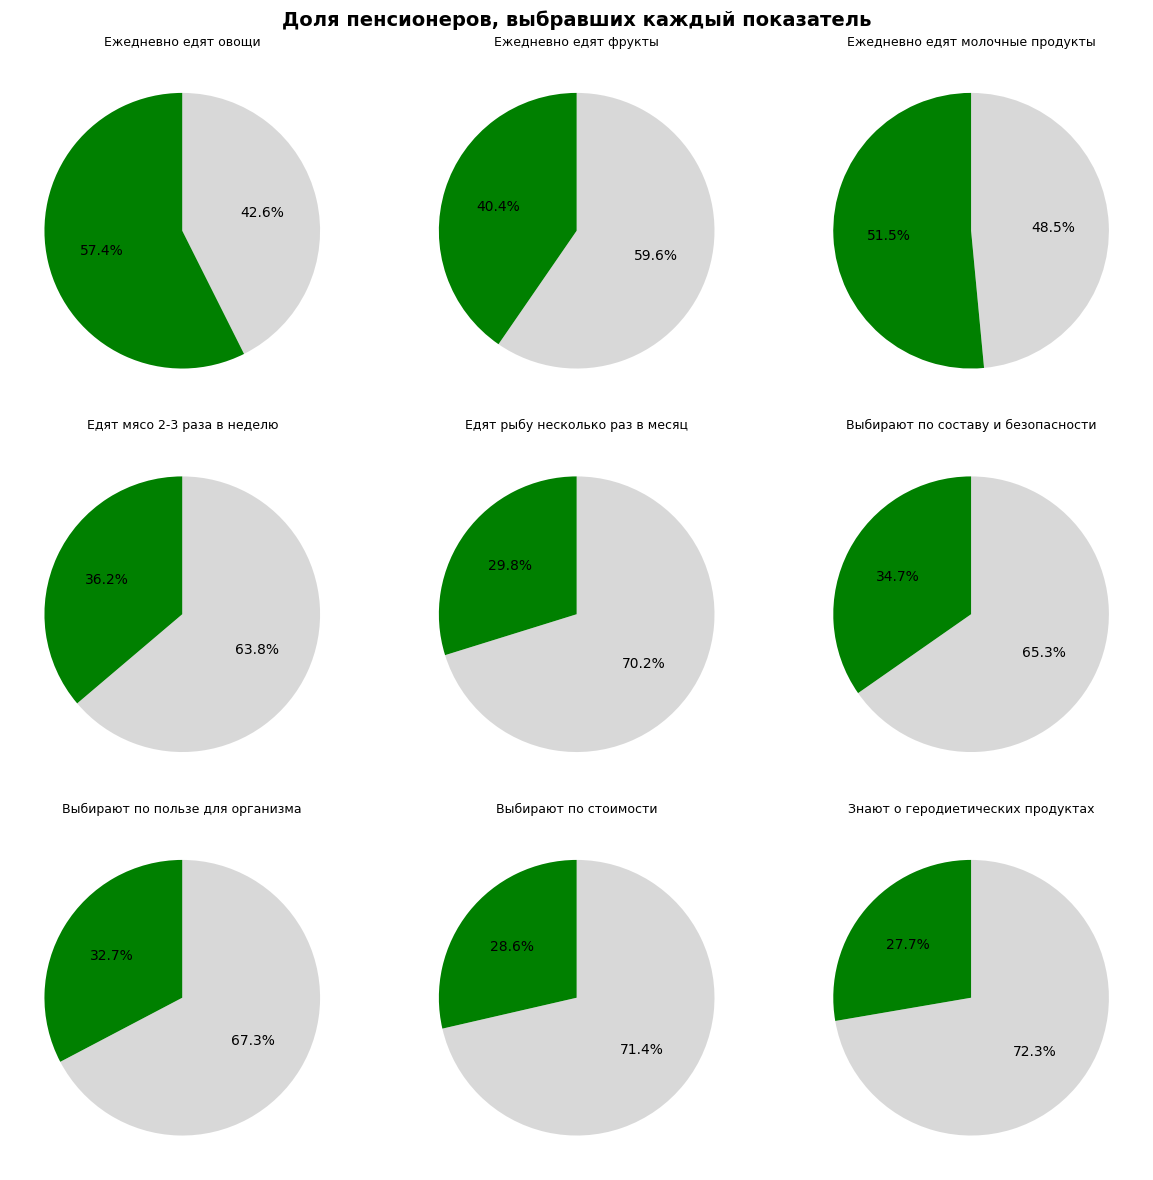

In [29]:
import requests
import re
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

url = "https://ivpt.ru/tocs/400/23/"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers, timeout=15)
soup = BeautifulSoup(response.text, 'html.parser')
page_text = soup.get_text()

patterns = {
    'Ежедневно едят овощи': r'овощи\s*\((\d+,\d+)%\)',
    'Ежедневно едят фрукты': r'фрукты\s*\((\d+,\d+)%\)',
    'Ежедневно едят молочные продукты': r'молочные продукты\s*\((\d+,\d+)%\)',
    'Едят мясо 2-3 раза в неделю': r'(\d+,\d+)%\s+респондентов\s+употребляют\s+мясо\s*',
    'Едят рыбу несколько раз в месяц': r'(\d+,\d+)%\s+–\s+рыбу\s*',
    'Выбирают по составу и безопасности': r'(\d+,\d+)%\s+человек\s+отметили\s+состав\s*',
    'Выбирают по пользе для организма': r'(\d+,\d+)%\s+–\s+пользу\s*',
    'Выбирают по стоимости': r'(\d+,\d+)%\s+–\s+стоимость',
    'Знают о геродиетических продуктах': r'(\d+,\d+)%\s+респондентов\s+имеют\s+представление\s+о\s+геродиетических\s*'
}

data = {}
for key, pattern in patterns.items():
    match = re.search(pattern, page_text, re.IGNORECASE)
    if match:
        value = float(match.group(1).replace(',', '.'))
        data[key] = value

if len(data) == 0:
    with open("ivpt_page_debug.txt", "w", encoding="utf-8") as f:
        f.write(page_text)
    exit()

df_astrakhan = pd.DataFrame(list(data.items()), columns=['Показатель', 'Доля'])

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Доля пенсионеров, выбравших каждый показатель', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(df):
        value = df.iloc[i]['Доля']
        label = df.iloc[i]['Показатель']
        sizes = [value,100-value]
        colors = ['green', 'gray']

        wedges, texts, autotexts = ax.pie(
            sizes,
            colors=colors,
            startangle=90,
            autopct=lambda pct: f'{pct:.1f}%' if pct > 0 else '',
            textprops={'fontsize': 10}
        )
        if len(wedges) > 1:
            wedges[1].set_edgecolor('none')
            wedges[1].set_alpha(0.3)
        ax.set_title(label, fontsize=9, pad=10)
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('astrakhan_pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()